In [1]:
# import os

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import jax
import jax.numpy as jnp

jax.config.update("jax_compilation_cache_dir", "./jax-caches")
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../"))

from desc import set_device
set_device("gpu")

In [3]:
import numpy as np
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True, threshold=sys.maxsize)
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.graph_objects as go

In [4]:
import desc

from desc.basis import *
from desc.backend import *
from desc.compute import *
from desc.coils import *
from desc.equilibrium import *
from desc.examples import *
from desc.grid import *
from desc.geometry import *
from desc.io import *

from desc.objectives import *
from desc.objectives.objective_funs import *
from desc.objectives.getters import *
from desc.objectives.normalization import compute_scaling_factors
from desc.objectives.utils import *
from desc.optimize._constraint_wrappers import *

from desc.transform import Transform
from desc.plotting import *
from desc.optimize import *
from desc.perturbations import *
from desc.profiles import *
from desc.compat import *
from desc.utils import *
from desc.magnetic_fields import *
from desc.particles import *
from diffrax import *

from desc.__main__ import main
from desc.vmec_utils import vmec_boundary_subspace
from desc.input_reader import InputReader
from desc.continuation import solve_continuation_automatic
from desc.compute.data_index import register_compute_fun
from desc.optimize.utils import solve_triangular_regularized

print_backend_info()

DESC version=0.17.1+28.g6b00f88da.
Using JAX backend: jax version=0.7.2, jaxlib version=0.7.2, dtype=float64.
Using device: NVIDIA GeForce RTX 4080 Laptop GPU (id=0), with 11.60 GB available memory.


# About this Notebook

We will get the free boundary equilibrium solution to the HBT base coils.

!!! What should be the profiles? Should we optimize for them? Or are there some good starting points?

In [5]:
# eq00 = load("./equilibria/desc-eq-HBT_limited.h5")
eq0 = load("./equilibria/desc-eq-HBT_105995_06.h5")
eq0 = load("./equilibria/desc-eq-HBT_105995_06-rev-curr.h5")

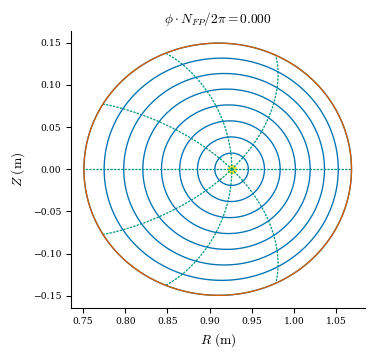

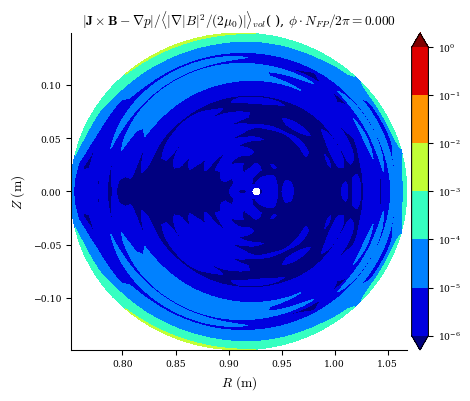

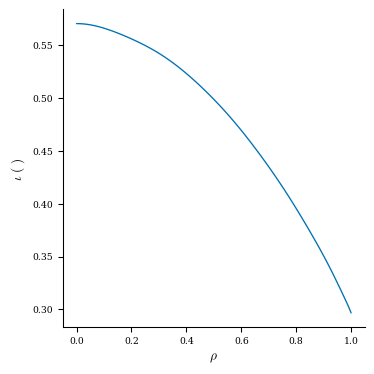

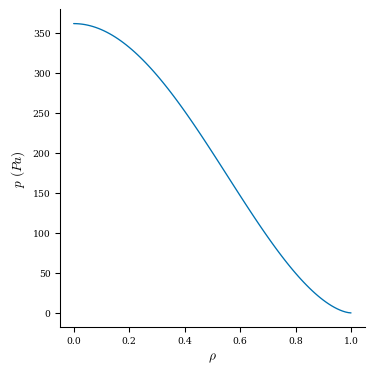

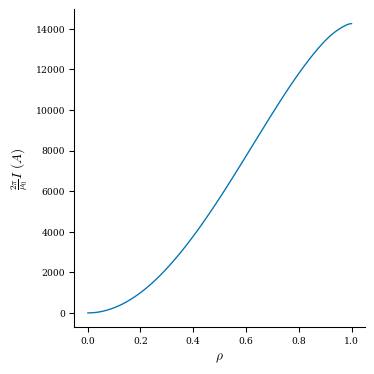

In [6]:
plot_surfaces(eq0)
plot_section(eq0, "|F|_normalized", log=True);
plot_1d(eq0, "iota")
plot_1d(eq0, "pressure")
plot_1d(eq0, "current");

In [33]:
field = load("./coils/hbt_default_coils.h5")
# for i in range(len(field.coils)):
#     for j in range(len(field.coils[i].coils)):
#         field.coils[i].coils[j].current *= -1
#         print(f"Switching current direction of {field.coils[i].coils[j].name}")

In [34]:
# scale the TF coil current
field.coils[0].coils[0].current *= -1

n_coils = 60
# B_center = mu_0 N I / (2pi r)
# I = B_center * (2pi r) / (mu_0 N)
# Given data of B = 0.32 T at R = 91.5 cm
I = 2 * np.pi * 0.915 * 0.32 / (mu_0 * n_coils)
tf_coils = FourierPlanarCoil(
    current=I, center=[0.9716, 0, 0], normal=[0, 1, 0], r_n=0.44196, name="TF coil"
)
tf_coils = CoilSet(tf_coils, NFP=n_coils, name="TF coilset", check_intersection=False)
field.coils[0] = tf_coils
# outer VF coils
for i in range(len(field.coils[1].coils)):
    field.coils[1].coils[i].current = -2240
# inner VF coils
for i in range(len(field.coils[2].coils)):
    field.coils[2].coils[i].current = 2240
# inner OH coils
for i in range(len(field.coils[3].coils)):
    field.coils[3].coils[i].current = -13240
# outer OH coils
for i in range(len(field.coils[4].coils)):
    field.coils[4].coils[i].current = -13240


# inner OH coils
for i in range(len(field.coils[3].coils)):
    field.coils[3].coils[i].current = -8000
# outer OH coils
for i in range(len(field.coils[4].coils)):
    field.coils[4].coils[i].current = -8000
# for i in range(len(field.coils)):
#     for j in range(len(field.coils[i].coils)):
#         field.coils[i].coils[j].current *= -1
#         print(f"Switching current direction of {field.coils[i].coils[j].name}")

In [ ]:
coils_without_tf = MixedCoilSet(field.coils[1:], check_intersection=False)
field = [ToroidalMagneticField(B0=0.32, R0=0.915), coils_without_tf]
eq = eq0.copy()
# eq.current *= -1
# eq.Psi *= -1
# eq.iota = eq.get_profile("iota")
coil_grid = LinearGrid(N=50)
objective = ObjectiveFunction(
    (
        BoundaryError(
            eq=eq,
            field=field,
            field_fixed=True,
            field_grid=coil_grid,
            source_grid=LinearGrid(
                rho=np.array([1.0]),
                M=eq.M_grid,
                N=eq.N_grid,
                NFP=eq.NFP if eq.N > 0 else 64,
                sym=False,
            ),
            eval_grid=LinearGrid(
                rho=np.array([1.0]),
                M=eq.M_grid,
                N=eq.N_grid,
                NFP=eq.NFP,
                sym=False,
            ),
        ),
        ToroidalFlux(
            eq,
            field=field,
            field_grid=coil_grid,
            eq_fixed=False,
            field_fixed=True,
        ),
    )
)
constraints = (
    ForceBalance(eq=eq, grid=QuadratureGrid(L=eq.L_grid, M=eq.M_grid, N=eq.N_grid, NFP=eq.NFP)),
    FixPressure(eq=eq),
    FixPsi(eq=eq),
)
if eq.current is not None:
    constraints += (FixCurrent(eq),)
else:
    constraints += (FixIota(eq),)

In [36]:
k = 4
R_modes = np.vstack(
    (
        # [0, 0, 0],
        eq.surface.R_basis.modes[np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :],
    )
)
Z_modes = eq.surface.Z_basis.modes[np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :]
bdry_constraints = (
    FixBoundaryR(eq=eq, modes=R_modes),
    FixBoundaryZ(eq=eq, modes=Z_modes),
)
eq, out = eq.optimize(
    objective,
    constraints + bdry_constraints,
    optimizer="proximal-lsq-exact",
    x_scale="ess",
    verbose=3,
    maxiter=30,
    ftol=1e-3,
    options={"solve_options":{"ftol": 1e-3, "gtol":0, "verbose":0}},
)

Building objective: Boundary error
Precomputing transforms
Timer: Precomputing transforms = 19.9 ms
Timer: Objective build = 1.03 sec
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 73.0 ms
Timer: Objective build = 81.1 ms
Timer: Objective build = 1.74 ms
Timer: Eq Update LinearConstraintProjection build = 83.8 ms
Timer: Proximal projection build = 2.88 sec
Building objective: fixed pressure
Building objective: fixed Psi
Building objective: fixed current
Building objective: lcfs R
Building objective: lcfs Z
Timer: Objective build = 180 ms
Timer: LinearConstraintProjection build = 170 ms
Number of parameters: 9
Number of objectives: 146
Timer: Initializing the optimization = 3.38 sec

Starting optimization
Using method: proximal-lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Met

In [38]:
eq.save('./desc-eq-HBT_105995_06-rev-curr-fb-k4-NFP64-sgN2-R0unfixed.h5')

(<Figure size 384.07x480.088 with 1 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>], dtype=object))

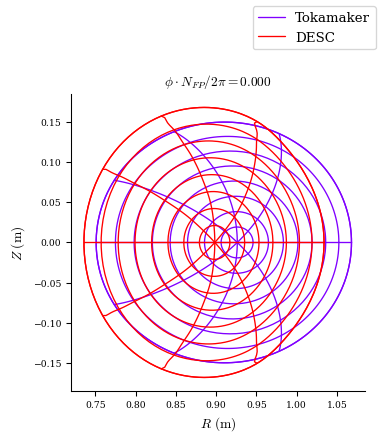

In [77]:
# this is not what I expect right now!
eq = load("./desc-eq-HBT_105995_06-rev-curr-fb-k4-NFP64-sgN2-R0fixed.h5")
plot_comparison([eq0, eq], labels=["Tokamaker", "DESC"])

In [78]:
data_desc = eq.compute(["R", "Z"], grid=LinearGrid(rho=np.array([1.0]), M=50, N=0))
data_toka = eq0.compute(["R", "Z"], grid=LinearGrid(rho=np.array([1.0]), M=50, N=0))
data_desc = np.vstack([data_desc["R"], data_desc["Z"]])
data_toka = np.vstack([data_toka["R"], data_toka["Z"]])
np.savetxt("desc_boundary_RZ.txt", data_desc)
np.savetxt("tokamaker_boundary_RZ.txt", data_toka)

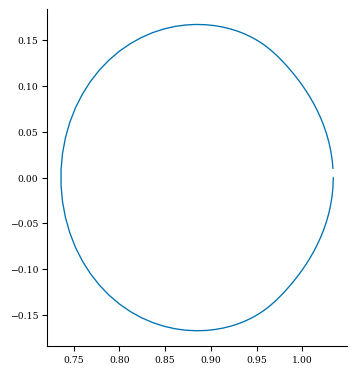

In [80]:
RZ = np.loadtxt("desc_boundary_RZ.txt")
R = RZ[0, :]
Z = RZ[1, :]
plt.plot(R, Z)
plt.gca().set_aspect("equal")

In [62]:
data_desc = eq0.compute(["R", "Z"], grid=LinearGrid(rho=np.array([0.0]), M=50, N=0))
data_desc["R"][0]

Array(0.9262, dtype=float64)

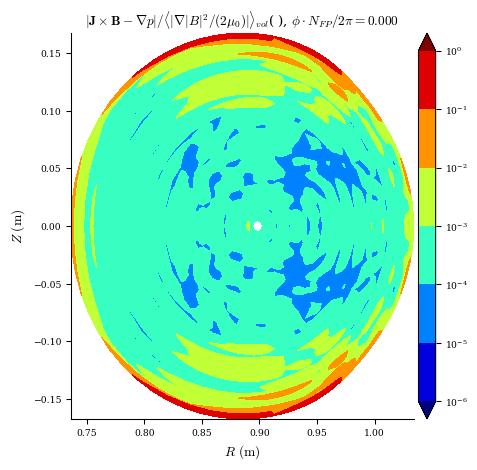

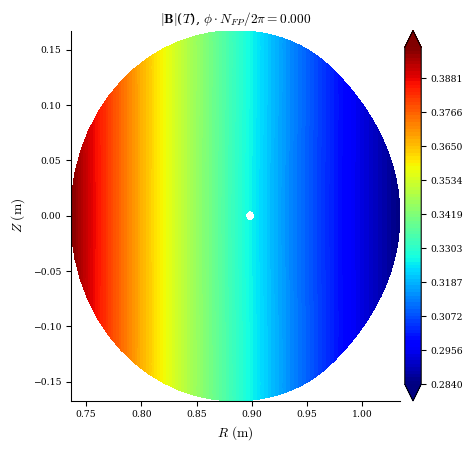

In [43]:
plot_section(eq, "|F|_normalized", log=True)
plot_section(eq, "|B|");

## Try to find the currents QuadraticFlux

In [44]:
eq = eq0.copy()
field = load("./coils/hbt_default_coils.h5")
n_coils = 60
# B_center = mu_0 N I / (2pi r)
# I = B_center * (2pi r) / (mu_0 N)
# Given data of B = 0.32 T at R = 91.5 cm
I = 2 * np.pi * 0.915 * 0.32 / (mu_0 * n_coils)
tf_coils = FourierPlanarCoil(
    current=I, center=[0.9716, 0, 0], normal=[0, 1, 0], r_n=0.44196, name="TF coil"
)
tf_coils = CoilSet(tf_coils, NFP=n_coils, name="TF coilset", check_intersection=False)
field.coils[0] = tf_coils
params_to_fix_field = [
    # tf coilset
    {"current": True, "r_n": True, "center": True, "normal": True},
    # vf outer coilset
    {"current": False, "r_n": True, "center": True, "normal": True},
    # vf inner coilset
    {"current": False, "r_n": True, "center": True, "normal": True},
    # oh inner coilset
    {"current": False, "r_n": True, "center": True, "normal": True},
    # oh outer coilset
    {"current": False, "r_n": True, "center": True, "normal": True},
]
constraints = (
    FixParameters(
        field,
        params_to_fix_field,
    ),
)

In [45]:
plasma_grid = LinearGrid(
    rho=np.array([1.0]),
    M=eq.M_grid,
    N=6,
    NFP=eq.NFP if eq.N > 0 else 64,
    sym=False,
)
coil_grid = LinearGrid(N=50)
obj = ObjectiveFunction(
    (
        QuadraticFlux(
            eq,
            field=field,
            source_grid=plasma_grid,
            eval_grid=plasma_grid,
            field_grid=coil_grid,
            vacuum=False,
            bs_chunk_size=10,
        ),
        ToroidalFlux(
            eq,
            field=field,
            field_grid=coil_grid,
            eq_fixed=True,
        )
    )
)

In [46]:
optimizer = Optimizer("lsq-exact")

(optimized_field,), _ = optimizer.optimize(
    field,
    objective=obj,
    constraints=constraints,
    maxiter=100,
    verbose=3,
    copy=True,
    ftol=1e-6,
    gtol=0,
    xtol=0,
)

Building objective: Quadratic flux
Precomputing transforms
Timer: Precomputing transforms = 1.27 sec
Building objective: toroidal-flux


/CODES/DESC/desc/utils.py:563: UserWarning: Pressure appears to be non-zero (max 362.03046614867463 Pa), this objective is unneeded at finite beta.
  warnings.warn(msg, err)
/CODES/DESC/desc/utils.py:563: UserWarning: Current appears to be non-zero (max 14249.793726100152 A), this objective is unneeded at finite beta.
  warnings.warn(msg, err)


Precomputing transforms
Timer: Precomputing transforms = 12.1 ms
Timer: Objective build = 2.12 sec
Building objective: fixed parameters
Building objective: fixed shift
Building objective: fixed rotation
Timer: Objective build = 328 ms
Timer: LinearConstraintProjection build = 336 ms
Number of parameters: 26
Number of objectives: 950
Timer: Initializing the optimization = 2.88 sec

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Method                : qr
Initial Trust Radius               : 8.292e-02
Maximum Trust Radius               : inf
Minimum Trust Radius               : 2.220e-16
Trust Radius Increase Ratio        : 2.000e+00
Trust Radius Decrease Ratio        : 2.500e-01
Trust Radius Increase Threshold    : 7.500e-01
Trust Radius Decrease Threshold    : 2.500e-01
------

Building objective: Boundary error
Precomputing transforms
Timer: Precomputing transforms = 30.3 ms
Building objective: toroidal-flux


/CODES/DESC/desc/utils.py:563: UserWarning: Pressure appears to be non-zero (max 362.03046614867463 Pa), this objective is unneeded at finite beta.
  warnings.warn(msg, err)
/CODES/DESC/desc/utils.py:563: UserWarning: Current appears to be non-zero (max 14249.793726100152 A), this objective is unneeded at finite beta.
  warnings.warn(msg, err)


Precomputing transforms
Timer: Precomputing transforms = 13.3 ms
Timer: Objective build = 2.02 sec
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 78.3 ms
Timer: Objective build = 88.8 ms
Timer: Objective build = 1.33 ms
Timer: Eq Update LinearConstraintProjection build = 93.0 ms
Timer: Proximal projection build = 3.61 sec
Building objective: fixed pressure
Building objective: fixed Psi
Building objective: fixed current
Building objective: lcfs R
Building objective: lcfs Z
Timer: Objective build = 152 ms
Timer: LinearConstraintProjection build = 175 ms
Number of parameters: 9
Number of objectives: 147
Timer: Initializing the optimization = 4.11 sec

Starting optimization
Using method: proximal-lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Method                : qr
Initial Tru

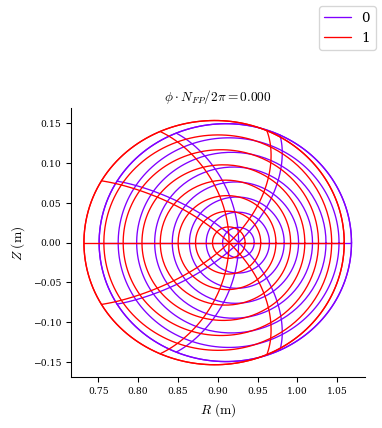

In [49]:
eq = eq0.copy()
eq.change_resolution(sym=True)
# eq.iota = eq.get_profile("iota")
coil_grid = LinearGrid(N=50)
objective = ObjectiveFunction(
    (
        BoundaryError(
            eq=eq,
            field=optimized_field,
            field_fixed=True,
            field_grid=coil_grid,
            source_grid=LinearGrid(
                rho=np.array([1.0]),
                M=eq.M_grid,
                N=eq.N_grid,
                NFP=eq.NFP if eq.N > 0 else 64,
                sym=False,
            ),
            eval_grid=LinearGrid(
                rho=np.array([1.0]),
                M=eq.M_grid,
                N=eq.N_grid,
                NFP=eq.NFP,
                sym=False,
            ),
        ),
        ToroidalFlux(
            eq,
            field=optimized_field,
            field_grid=coil_grid,
            eq_fixed=False,
            field_fixed=True,
        ),
    )
)
constraints = (
    ForceBalance(
        eq=eq, grid=QuadratureGrid(L=eq.L_grid, M=eq.M_grid, N=eq.N_grid, NFP=eq.NFP)
    ),
    FixPressure(eq=eq),
    FixPsi(eq=eq),
)
if eq.current is not None:
    constraints += (FixCurrent(eq),)
else:
    constraints += (FixIota(eq),)

k = 4
R_modes = eq.surface.R_basis.modes[np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :]
Z_modes = eq.surface.Z_basis.modes[np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :]
bdry_constraints = (
    FixBoundaryR(eq=eq, modes=R_modes),
    FixBoundaryZ(eq=eq, modes=Z_modes),
)
eq, out = eq.optimize(
    objective,
    constraints + bdry_constraints,
    optimizer="proximal-lsq-exact",
    x_scale="ess",
    verbose=3,
    maxiter=100,
    ftol=1e-3,
)
plot_comparison([eq0, eq]);

In [81]:
eq = load("./desc-eq-HBT_105995_06-rev-curr-stage2-fb-k4.h5")
optimized_field = load("./coils-eq-HBT_105995_06-rev-curr-stage2-fb-k4.h5")

In [82]:
data_desc = eq.compute(["R", "Z"], grid=LinearGrid(rho=np.array([1.0]), M=50, N=0))
data_desc = np.vstack([data_desc["R"], data_desc["Z"]])
np.savetxt("desc_boundary_RZ_after_current_change.txt", data_desc)

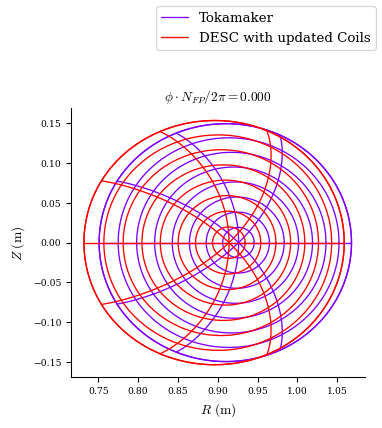

In [64]:
plot_comparison([eq0, eq], labels=["Tokamaker", "DESC with updated Coils"]);

In [50]:
eq.save("./desc-eq-HBT_105995_06-rev-curr-stage2-fb-k4.h5")
optimized_field.save("./coils-eq-HBT_105995_06-rev-curr-stage2-fb-k4.h5")

In [ ]:
# eq.save("./equilibria/desc-eq-HBT_105995_06-rev-curr-stage2-fb.h5")
# optimized_field.save("./coils/coils-eq-HBT_105995_06-rev-curr-stage2-fb.h5")

In [67]:
currents = optimized_field._all_currents()
currents, currents[60:]

(Array([  24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,   24400.    ,  -11628.458 ,  -11628.4634, -364394.644 , -364395.779 , -394051.1297, -394052.2815, -327582.5731, -327583.477 , -135507.016 , -135507.3618,  209205.383 

In [85]:
field = load("./coils/hbt_default_coils.h5")
# outer VF coils
for i in range(len(field.coils[1].coils)):
    field.coils[1].coils[i].current = -2240
# inner VF coils
for i in range(len(field.coils[2].coils)):
    field.coils[2].coils[i].current = 2240
# inner OH coils
for i in range(len(field.coils[3].coils)):
    field.coils[3].coils[i].current = -13240
# outer OH coils
for i in range(len(field.coils[4].coils)):
    field.coils[4].coils[i].current = -13240


# inner OH coils
for i in range(len(field.coils[3].coils)):
    field.coils[3].coils[i].current = -8000
# outer OH coils
for i in range(len(field.coils[4].coils)):
    field.coils[4].coils[i].current = -8000
i = 0
j = 0
for coil in field:
    for c in coil:
        if j != 0:
            print(c.name + f" at Z = {c.center[2]*100:.3f} cm has current = {c.current/1000:.3f} kA")
        j += 1

Outer VF coil at Z = 65.052 cm has current = -2.240 kA
Outer VF coil at Z = -65.052 cm has current = -2.240 kA
Inner VF coil at Z = 35.084 cm has current = 2.240 kA
Inner VF coil at Z = -35.084 cm has current = 2.240 kA
Inner VF coil at Z = 36.354 cm has current = 2.240 kA
Inner VF coil at Z = -36.354 cm has current = 2.240 kA
Inner VF coil at Z = 37.624 cm has current = 2.240 kA
Inner VF coil at Z = -37.624 cm has current = 2.240 kA
Inner VF coil at Z = 38.894 cm has current = 2.240 kA
Inner VF coil at Z = -38.894 cm has current = 2.240 kA
Inner VF coil at Z = 40.164 cm has current = 2.240 kA
Inner VF coil at Z = -40.164 cm has current = 2.240 kA
Inner VF coil at Z = 41.434 cm has current = 2.240 kA
Inner VF coil at Z = -41.434 cm has current = 2.240 kA
Inner OH coil at Z = 4.286 cm has current = -8.000 kA
Inner OH coil at Z = -4.286 cm has current = -8.000 kA
Inner OH coil at Z = 12.859 cm has current = -8.000 kA
Inner OH coil at Z = -12.859 cm has current = -8.000 kA
Inner OH coil a